## FIGURE 1 for WUS CMIP6 WARMING PAPER

In [1]:
import netCDF4
#import h5netcdf
import xarray as xr
import scipy
import os
#os.environ['ESMFMKFILE'] = '/home/tessj/miniconda3/envs/xarrayxesmf/lib/esmf.mk'
import xesmf as xe
import numpy as np
#import xeofs as xeo
import scipy.stats as stats
import warnings
import matplotlib.pyplot as plt
import scipy.signal as signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy
import seaborn as sns

def fix_coords_lon(ds):
    ds = ds.assign_coords(longitude=(((ds.longitude + 180) % 360) - 180)).sortby(['longitude','latitude'])
    return ds

def fix_coords_lon_lat(ds):
    ds = ds.assign_coords(lon=(((ds.lon + 180) % 360) - 180)).sortby(['lon','lat'])
    return ds

import statsmodels.api as sm
import json

In [2]:
modmembers_geq3_tas = {} 
with open('/home/tessj/wus_temp_trends/modmembers/modmembers_tas_total.json', 'r') as file:
        modmembers_geq3_tas = json.load(file)
        

In [3]:
# get any model regridded to 
tas_test = xr.open_dataset(f'/d3/tessj/data/CMIP6/for_tess/ACCESS-ESM1-5/tas_Amon_ACCESS-ESM1-5_historical_r3i1p1f1_18500101-20141231_regrid.nc').sel(time=slice('1941-01-01', '2014-12-31'))

# use ERA5 land-sea mask
landmask = fix_coords_lon(xr.open_dataarray('/home/tessj/wildfire-clim/land_sea_mask.nc').isel(time=-1).load()).rename({'latitude':'lat', 'longitude':'lon'}).drop(['expver','time'])
landmask = landmask.interp_like(tas_test)
landmask = landmask.where(landmask>0.4, np.nan)
landmask = landmask/landmask

In [4]:
# WUS region
wusbox = [-125, -102, 32,  49]

In [5]:
# latitude weights
weights = np.cos(np.deg2rad(landmask.lat))

In [6]:
# datetimes
datetimes_np64 = np.arange('1941-01', '2025-01', dtype='datetime64[M]')
datetimes_np64 = datetimes_np64.astype('datetime64[ns]')

### Open GISS and Berkeley observational data

In [7]:
gisstemp = xr.open_dataset('/home/tessj/wus_temp_trends/gistemp250_GHCNv4.nc').sel(time=slice('1941-01-01', '2024-12-31')).assign_coords({'time':datetimes_np64}).drop('time_bnds')

In [8]:
gisstemp_wus = gisstemp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
gisstemp_weights = np.cos(np.deg2rad(gisstemp.lat))

gisstemp_wus_avg = gisstemp_wus.weighted(gisstemp_weights).mean(['lon','lat'])
gisstemp_globland_avg = gisstemp.weighted(gisstemp_weights).mean(['lon','lat'])

In [9]:
gisstemp_wus_avg_szn = {}
gisstemp_globland_avg_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    gisstemp_wus_avg_szn[szn] = gisstemp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    gisstemp_globland_avg_szn[szn] = gisstemp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [10]:
berk_temp = xr.open_dataset('/home/tessj/wus_temp_trends/Complete_TAVG_LatLong1.nc', decode_times=True).isel(time=slice(12*191,3300)).assign_coords({'time':gisstemp.time}).rename({'latitude':'lat', 'longitude':'lon'})

In [11]:
berk_temp_wus = berk_temp.sel(lon=slice(wusbox[0],wusbox[1]), lat=slice(wusbox[2],wusbox[3]))
berk_temp_na = berk_temp.sel(lon=slice(wusbox[0],-90), lat=slice(20,60))

berk_temp_weights = np.cos(np.deg2rad(berk_temp.lat))

berk_temp_wus_avg = berk_temp_wus.weighted(berk_temp_weights).mean(['lon','lat'])
berk_temp_globland_avg = berk_temp.weighted(berk_temp_weights).mean(['lon','lat'])

In [12]:
berk_temp_wus_avg_trend = berk_temp_wus_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
berk_temp_globland_avg_trend = berk_temp_globland_avg.sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [13]:
berk_temp_wus_avg_szn = {}
berk_temp_globland_avg_szn = {}
berk_temp_wus_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_szn[szn] = berk_temp_na.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_wus_avg_szn[szn] = berk_temp_wus_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))
    berk_temp_globland_avg_szn[szn] = berk_temp_globland_avg.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [14]:
berk_temp_wus_avg_trend_szn = {}
berk_temp_globland_avg_trend_szn = {}
berk_temp_wus_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_globland_avg_trend_szn[szn] = berk_temp_globland_avg_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)
    berk_temp_wus_trend_szn[szn] = berk_temp_wus_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

In [15]:
[berk_temp_wus_avg_trend_szn[szn].temperature_polyfit_coefficients.item()*45 for szn in berk_temp_wus_avg_trend_szn.keys()]

[0.3317690127687514, 0.658451650063264, 1.8910986129076108, 1.1415742399361546]

In [16]:
berk_temp_wus_avg_trend_80_14_szn = {}

for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    berk_temp_wus_avg_trend_80_14_szn[szn] = berk_temp_wus_avg_szn[szn].sel(time=slice('1980-01-01','2014-12-31')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)


### Open CMIP6 temperature data

In [17]:
ds_tas_avg = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_avgs.nc')
ds_tas_wus = xr.open_dataset('/home/tessj/wus_temp_trends/cmip6_ensmean_tas_na.nc')

In [18]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim


In [19]:
ds_tas_avg_51_80_m_clim = ds_tas_avg.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_avg_51_80_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_51_80_m_clim

ds_tas_avg_m_clim = ds_tas_avg.groupby('time.month').mean('time')
ds_tas_avg_m_anom = ds_tas_avg.groupby('time.month') - ds_tas_avg_m_clim

In [20]:
ds_tas_wus_51_80_m_clim = ds_tas_wus.sel(time=slice('1951-01-01', '1980-12-31')).groupby('time.month').mean('time')
ds_tas_wus_51_80_m_anom = ds_tas_wus.groupby('time.month') - ds_tas_wus_51_80_m_clim

In [21]:
ds_tas_avg_51_80_m_anom_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_szn[szn] = ds_tas_avg_51_80_m_anom.resample(time='QS-JAN').mean('time').isel(time=slice(i,None,4))

In [22]:
ds_tas_avg_51_80_m_anom_trend_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']):
    ds_tas_avg_51_80_m_anom_trend_szn[szn] = ds_tas_avg_51_80_m_anom_szn[szn].sel(time=slice('1980-01-01','2024-01-01')).groupby('time.year').mean('time').polyfit(dim='year', deg=1).sel(degree=1)

### Smooth with LOWESS filter

In [23]:
# lowess filter with frac=0.2
smoothed_wus = sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom.time, endog=ds_tas_avg_51_80_m_anom.tas_wus.mean('model'), frac=0.4)
smoothed_globland = sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom.time, endog=ds_tas_avg_51_80_m_anom.tas_globland.mean('model'), frac=0.4)

In [24]:
smoothed_wus_szn = {}
smoothed_globland_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']): 
    # lowess filter with frac
    smoothed_wus_szn[szn] = sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom_szn[szn].time, endog=ds_tas_avg_51_80_m_anom_szn[szn].tas_wus.mean('model'), frac=0.4)
    smoothed_globland_szn[szn] = sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom_szn[szn].time, endog=ds_tas_avg_51_80_m_anom_szn[szn].tas_globland.mean('model'), frac=0.4)

In [25]:
smoothed_wus_bymodel = {}
for model in ds_tas_avg_51_80_m_anom.model:
    smoothed_wus_bymodel[model.item()] =  sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom.time.values, endog=ds_tas_avg_51_80_m_anom.tas_wus.sel(model=model).values, frac=0.4)

In [26]:
smoothed_wus_bymodel_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']): 
    smoothed_wus_bymodel_szn[szn] = {}
    for model in ds_tas_avg_51_80_m_anom_szn[szn].model:
        smoothed_wus_bymodel_szn[szn][model.item()] =  sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom_szn[szn].time.values, endog=ds_tas_avg_51_80_m_anom_szn[szn].tas_wus.sel(model=model).values, frac=0.4)

In [27]:
smoothed_globland_bymodel = {}
for model in ds_tas_avg_51_80_m_anom.model:
    smoothed_globland_bymodel[model.item()] =  sm.nonparametric.lowess(exog=ds_tas_avg_51_80_m_anom.time.values, endog=ds_tas_avg_51_80_m_anom.tas_globland.sel(model=model).values, frac=0.4)

In [28]:
# lowess filter with frac=0.2
smoothed_wus_giss = sm.nonparametric.lowess(exog=gisstemp_wus_avg.time, endog=gisstemp_wus_avg.tempanomaly, frac=0.4)
smoothed_globland_giss = sm.nonparametric.lowess(exog=gisstemp_globland_avg.time, endog=gisstemp_globland_avg.tempanomaly, frac=0.4)

In [29]:
smoothed_wus_giss_szn = {}
smoothed_globland_giss_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']): 
    # lowess filter with frac
    smoothed_wus_giss_szn[szn] = sm.nonparametric.lowess(exog=gisstemp_wus_avg_szn[szn].time, endog=gisstemp_wus_avg_szn[szn].tempanomaly, frac=0.4)
    smoothed_globland_giss_szn[szn] = sm.nonparametric.lowess(exog=gisstemp_globland_avg_szn[szn].time, endog=gisstemp_globland_avg_szn[szn].tempanomaly, frac=0.4)

In [30]:
# lowess filter with frac=0.2
smoothed_wus_berk = sm.nonparametric.lowess(exog=berk_temp_wus_avg.time, endog=berk_temp_wus_avg.temperature, frac=0.4)
smoothed_globland_berk = sm.nonparametric.lowess(exog=berk_temp_globland_avg.time, endog=berk_temp_globland_avg.temperature, frac=0.4)

In [31]:
smoothed_wus_berk_szn = {}
smoothed_globland_berk_szn = {}
for i, szn in enumerate(['JFM', 'AMJ', 'JAS', 'OND']): 
    # lowess filter with frac
    smoothed_wus_berk_szn[szn] = sm.nonparametric.lowess(exog=berk_temp_wus_avg_szn[szn].time, endog=berk_temp_wus_avg_szn[szn].temperature, frac=0.4)
    smoothed_globland_berk_szn[szn] = sm.nonparametric.lowess(exog=berk_temp_globland_avg_szn[szn].time, endog=berk_temp_globland_avg_szn[szn].temperature, frac=0.4)

In [32]:
# if adding ERA5
# lowess filter with frac=0.2
#smoothed_wus_era5_t2m = sm.nonparametric.lowess(exog=era5_sl_wus_51_80_m_anom_avg.time, endog=era5_sl_wus_51_80_m_anom_avg.t2m, frac=0.4)
#smoothed_wus_era5_tp = sm.nonparametric.lowess(exog=era5_sl_wus_51_80_m_anom_avg.time, endog=era5_sl_wus_51_80_m_anom_avg.tp, frac=0.4)


In [33]:
ds_tas_avg_51_80_m_anom_mmm = ds_tas_avg_51_80_m_anom.mean('model')

In [34]:
globland_model_am_trends = 45*ds_tas_avg_51_80_m_anom.sel(time=slice('1980-01-01','2024-12-31')).groupby('time.year').mean('time').tas_globland.polyfit(dim='year', deg=1).sel(degree=1).polyfit_coefficients

In [35]:
globland_gistemp_am_trend = 45*gisstemp_globland_avg.sel(time=slice('1980-01-01','2024-12-31')).groupby('time.year').mean('time').tempanomaly.polyfit(dim='year', deg=1).sel(degree=1).polyfit_coefficients
globland_gistemp_am_trend

<xarray.DataArray 'polyfit_coefficients' ()>
array(1.44398763)
Coordinates:
    degree   int64 1

In [36]:
globland_berk_am_trend = 45*berk_temp_globland_avg.sel(time=slice('1980-01-01','2024-12-31')).groupby('time.year').mean('time').temperature.polyfit(dim='year', deg=1).sel(degree=1).polyfit_coefficients
globland_berk_am_trend

<xarray.DataArray 'polyfit_coefficients' ()>
array(1.36275567)
Coordinates:
    degree   int64 1

In [37]:
# percentile of giss global land temp trend within model trends
stats.percentileofscore(globland_model_am_trends, globland_gistemp_am_trend, kind='mean')

25.0

In [38]:
# percentile of berkeley global land temp trend within model trends
stats.percentileofscore(globland_model_am_trends, globland_berk_am_trend, kind='mean')

20.833333333333336

### Full figure

In [40]:
szns = ['JFM', 'AMJ', 'JAS', 'OND']
label_letters = ['c.','d.','e.','f.']

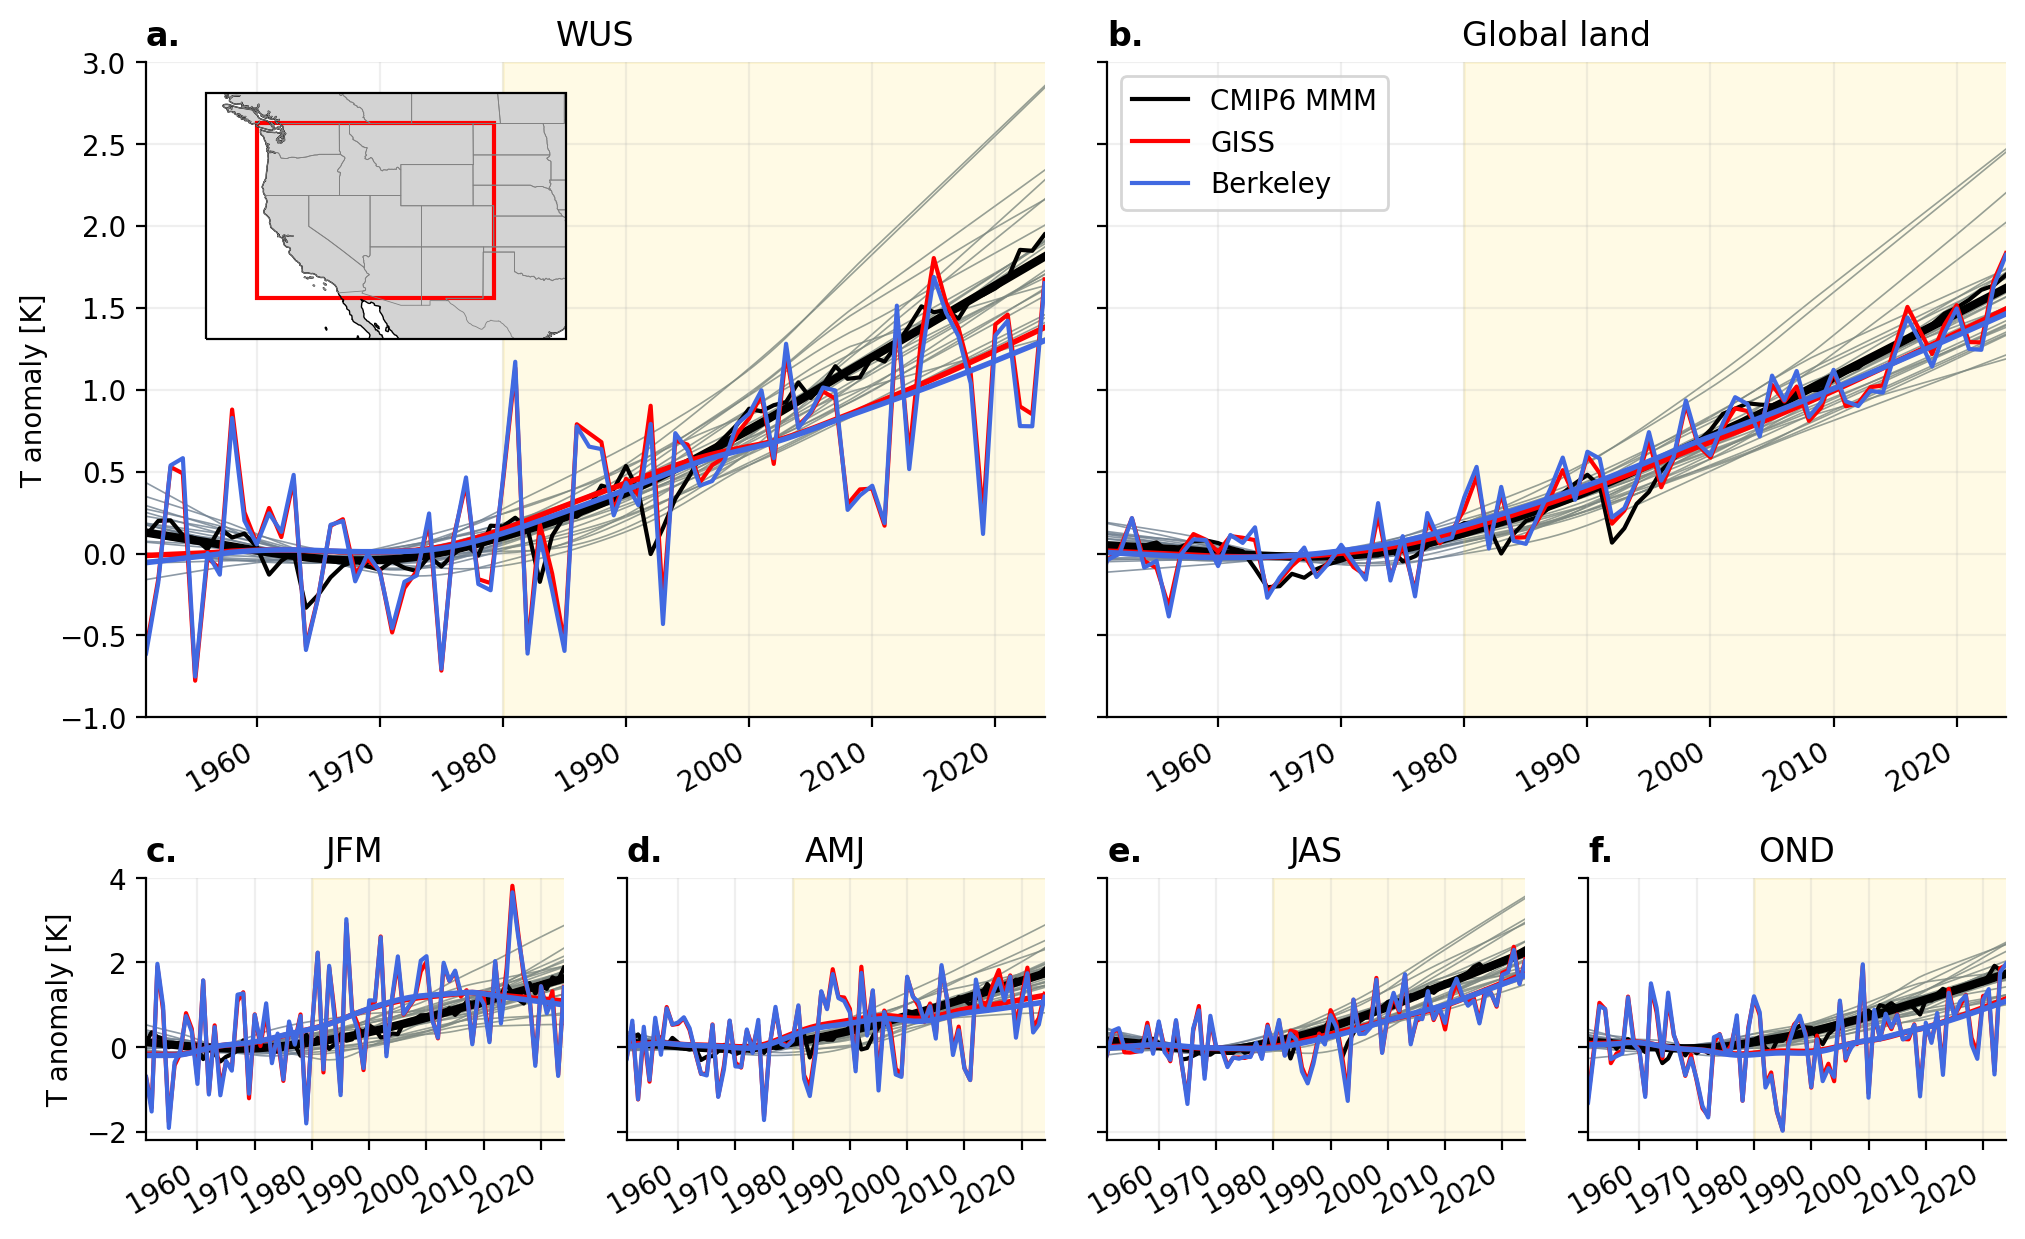

In [57]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
import cartopy.feature as cfeature


fig = plt.figure(figsize=(12,7), dpi=200)
gs = fig.add_gridspec(2,4, height_ratios=[2.5,1], hspace=0.35, wspace=0.15)

# TOP ROW

ax = fig.add_subplot(gs[0,0:2])
ds_tas_avg_51_80_m_anom_mmm.resample(time='AS').mean('time').tas_wus.plot(ax=ax, c='k', lw=1.5, label='CMIP6 MMM')
ax.plot(ds_tas_avg_51_80_m_anom.time, smoothed_wus[:,1], lw=3, c='k')
for model in ds_tas_avg_51_80_m_anom.model:
    ax.plot(ds_tas_avg_51_80_m_anom.time, smoothed_wus_bymodel[model.item()][:,1], lw=0.6, zorder=0, alpha=0.8, c='slategrey')
gisstemp_wus_avg.resample(time='AS').mean('time').tempanomaly.plot(ax=ax, c='r', lw=1.5, label='GISS')
ax.plot(gisstemp_wus_avg.time, smoothed_wus_giss[:,1], c='r', lw=2)
berk_temp_wus_avg.resample(time='AS').mean('time').temperature.plot(ax=ax, c='royalblue', lw=1.5, label='Berkeley')
ax.plot(berk_temp_wus_avg.time, smoothed_wus_berk[:,1], c='royalblue', lw=2)
ax.axvspan('1980-01-01', '2025-01-01', color='gold', alpha=0.1)
ax.grid(alpha=0.2)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlim(gisstemp_wus_avg.time[120], gisstemp_wus_avg.resample(time='AS').mean('time').time[-1])
ax.set_ylim(-1,3)
ax.set_ylabel('T anomaly [K]')
ax.set_xlabel('')
ax.set_title('WUS')
ax.set_title('a.', loc='left', fontweight='bold')


# inset in panel a
axins = fig.add_axes([0.15, 0.68, 0.15, 0.18], projection=ccrs.PlateCarree())

axins.set_extent([-130, -95, 28, 52], crs=ccrs.PlateCarree())
axins.add_feature(cfeature.LAND, facecolor='lightgrey')
axins.add_feature(cfeature.OCEAN, facecolor='white')
axins.add_feature(cfeature.COASTLINE, linewidth=0.5)
axins.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='grey')

rect = Rectangle((wusbox[0], wusbox[2]), wusbox[1]-wusbox[0], wusbox[3]-wusbox[2],
                 linewidth=1.5, edgecolor='red', facecolor='none',
                 transform=ccrs.PlateCarree())
axins.add_patch(rect)

axins.set_xticks([])
axins.set_yticks([])


ax1 = fig.add_subplot(gs[0,2:4], sharey=ax)
ds_tas_avg_51_80_m_anom_mmm.resample(time='AS').mean('time').tas_globland.plot(ax=ax1, c='k', lw=1.5, label='CMIP6 MMM')
ax1.plot(ds_tas_avg_51_80_m_anom.time, smoothed_globland[:,1], lw=3, c='k')
for model in ds_tas_avg_51_80_m_anom.model:
    ax1.plot(ds_tas_avg_51_80_m_anom.time, smoothed_globland_bymodel[model.item()][:,1], lw=0.6, zorder=0, alpha=0.8, c='slategrey')
gisstemp_globland_avg.resample(time='AS').mean('time').tempanomaly.plot(ax=ax1, c='r', lw=1.5, label='GISS')
ax1.plot(gisstemp_globland_avg.time, smoothed_globland_giss[:,1], c='r', lw=2)
berk_temp_globland_avg.resample(time='AS').mean('time').temperature.plot(ax=ax1, c='royalblue', lw=1.5, label='Berkeley')
ax1.plot(berk_temp_globland_avg.time, smoothed_globland_berk[:,1], c='royalblue', lw=2)
ax1.grid(alpha=0.2)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.set_xlim(gisstemp_globland_avg.time[120], gisstemp_globland_avg.resample(time='AS').mean('time').time[-1])
ax1.axvspan('1980-01-01', '2025-01-01', color='gold', alpha=0.1)
ax1.set_ylabel('')
ax1.tick_params(labelleft=False)
ax1.set_xlabel('')
ax1.set_title('Global land')
ax1.set_title('b.', loc='left', fontweight='bold')
ax1.set_ylim(-1,3)
ax1.legend()


# BOTTOM ROW

ax_szn0 = fig.add_subplot(gs[1,0])

for ii, szn in enumerate(szns):
    if ii == 0:
        ax = ax_szn0
    else:
        ax = fig.add_subplot(gs[1,ii], sharey=ax_szn0)

    ds_tas_avg_51_80_m_anom_szn[szn].tas_wus.resample(time='AS').mean(['time','model']).plot(ax=ax, c='k', lw=1.5, label='CMIP6 MMM')
    ax.plot(ds_tas_avg_51_80_m_anom_szn[szn].time, smoothed_wus_szn[szn][:,1], lw=3, c='k')
    for model in ds_tas_avg_51_80_m_anom_szn[szn].model:
        ax.plot(ds_tas_avg_51_80_m_anom_szn[szn].time, smoothed_wus_bymodel_szn[szn][model.item()][:,1], lw=0.6, zorder=0, alpha=0.8, c='slategrey')
    gisstemp_wus_avg_szn[szn].resample(time='AS').mean('time').tempanomaly.plot(ax=ax, c='r', lw=1.5, label='GISS')
    ax.plot(gisstemp_wus_avg_szn[szn].time, smoothed_wus_giss_szn[szn][:,1], c='r', lw=2)
    berk_temp_wus_avg_szn[szn].resample(time='AS').mean('time').temperature.plot(ax=ax, c='royalblue', lw=1.5, label='Berkeley')
    ax.plot(berk_temp_wus_avg_szn[szn].time, smoothed_wus_berk_szn[szn][:,1], c='royalblue', lw=2)
    ax.axvspan('1980-01-01', '2025-01-01', color='gold', alpha=0.1)
    ax.grid(alpha=0.2)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xlim(gisstemp_wus_avg.time[120], gisstemp_wus_avg.resample(time='AS').mean('time').time[-1])
    if ii==0: ax.set_ylabel('T anomaly [K]')
    else:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)
    ax.set_xlabel('')
    ax.set_ylim(-2.2,4)
    ax.set_title(f'{szn}')
    ax.set_title(f'{label_letters[ii]}', loc='left', fontweight='bold')

plt.show()
